In [ ]:
import gc
import itertools
import math
import os
import random
import sys
from collections import Counter, defaultdict
from copy import deepcopy
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Any, Callable, Literal, TypeAlias

import einops
import numpy as np
import pandas as pd
import torch as t
from datasets import load_dataset
from IPython.display import clear_output, display
from jaxtyping import Float, Int
from rich import print as rprint
from rich.table import Table

from transformer_lens import HookedTransformer, HookedTransformerConfig
from tabulate import tabulate
from torch import Tensor, nn
from torch.nn import functional as F
from tqdm.auto import tqdm
from transformer_lens import ActivationCache, loading_from_pretrained
from transformer_lens.hook_points import HookPoint
from transformer_lens.utils import get_act_name, to_numpy
from transformer_lens import utils

import matplotlib.pyplot as plt
import seaborn as sns
import torch

from scipy.sparse import csr_array
from scipy.sparse.csgraph import maximum_bipartite_matching, min_weight_full_bipartite_matching

device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")

## Model & State_dict Loading 

In [2]:
import importlib

arch = "gpt2"

# ------------------- Load Model Config -------------------

def load_named_config(module_name: str, config_name: str) -> dict:
    """
    Import a module that defines CONFIGS: Dict[str, Dict[str, Any]]
    and return CONFIGS[config_name].
    """
    try:
        mod = importlib.import_module(module_name)
    except Exception as e:
        raise ImportError(f"Could not import config module '{module_name}': {e}") from e

    if not hasattr(mod, "CONFIGS"):
        raise AttributeError(f"Module '{module_name}' does not define CONFIGS.")

    CONFIGS = getattr(mod, "CONFIGS")
    if config_name not in CONFIGS:
        available = ", ".join(sorted(CONFIGS.keys()))
        raise KeyError(f"Config '{config_name}' not found in {module_name}. Available: {available}")

    return dict(CONFIGS[config_name])  # copy so we can tweak

cfg_dict = load_named_config("model_configs", arch)


# ------------------- Model Configuration -------------------

# Build HookedTransformerConfig using the loaded config
cfg = HookedTransformerConfig(
    n_layers=cfg_dict["n_layers"],
    d_model=cfg_dict["d_model"],
    n_heads=cfg_dict["n_heads"],
    d_head=cfg_dict["d_head"],
    d_mlp=cfg_dict.get("d_mlp", None),
    n_ctx=cfg_dict["n_ctx"],
    act_fn=cfg_dict.get("act_fn", "gelu"),
    d_vocab=cfg_dict["d_vocab"],
    init_weights=True,
    tokenizer_name=cfg_dict["tokenizer_name"],
    model_name=cfg_dict.get("model_name", arch),
    attn_only=cfg_dict.get("attn_only", False),
)

In [ ]:
# Constants
SCRATCH = "Path to root directory"
NUM_LAYERS = cfg.n_layers
NUM_HEADS = cfg.n_heads
ATTN_ONLY = cfg.attn_only


chkpt_dir = SCRATCH + "chkpts/" + arch
SEEDS = [i for i in range(1, 51)]
if "gpt2" in arch:
    SEEDS = [i for i in range(1, 6)]
chkpt_file = "final.pt"
shard = 9
epoch = 1

# Load models
models = []
for SEED in SEEDS:
    cfg.seed = SEED
    cfg.init_weights = True
    model = HookedTransformer(cfg)
    models.append(model)

for ind, SEED in enumerate(SEEDS):
    if (arch == "gpt2") or (arch == "gpt2_wd"):
        model_state_dict = t.load(chkpt_dir + f"/gpt2_seed{SEED}_shard{shard}_epoch{epoch}_owt/{chkpt_file}")
        models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)
    else:
        if ATTN_ONLY:
            model_state_dict = t.load(
                chkpt_dir + f"/causal_attn_only_l{NUM_LAYERS}_h{NUM_HEADS}_seed{SEED}_epoch{epoch}_c4_gelu/{chkpt_file}"
            )
            models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)

        else:
            model_state_dict = t.load(
                chkpt_dir + f"/causal_attn_l{NUM_LAYERS}_h{NUM_HEADS}_seed{SEED}_epoch{epoch}_c4_gelu/{chkpt_file}"
            )
            models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)

## Prompt Sentences Data

In [4]:
import pickle

prompts_file = "100_prompts"

with open(f"./{prompts_file}.pkl", "rb") as f:
    prompts = pickle.load(f)

print(f"Loaded {len(prompts)} prompts from ./{prompts_file}.pkl")

Loaded 100 prompts from ./100_prompts.pkl


## Caching Model Activations & Attention Scores

In [5]:
# Setting device to CPU as GPU memory is insufficient for this computation, but for smaller number of prompts/models it can be set to GPU
device = 'cpu'

# run prompts to collect caches (using CPU to avoid CUDA OOM)
prompts_cache = []
for prompt in prompts:
    cache_for_prompt = []
    for ind in range(len(SEEDS)):
        _, cache_i = models[ind].run_with_cache(prompt, remove_batch_dim=True)
        # Keep cache on CPU
        cache_i = cache_i.to('cpu')
        cache_for_prompt.append(cache_i)
    prompts_cache.append(cache_for_prompt)

## Within-layer uniqueness of attention heads

In [6]:
# Define function to extract lower triangular part of attention matrix
def lower_triang(mat):
    
    lower_triangular_mat = torch.tril(mat)
    mask = torch.tril(torch.ones_like(mat, device=device)).bool()
    lower_triangular_vec = lower_triangular_mat[mask]
    return lower_triangular_vec

# Initialize cosine similarity module
cos = t.nn.CosineSimilarity(dim=1, eps=1e-08)

# Constants
NUM_MODELS = len(models)
NUM_HEADS = models[0].cfg.n_heads
NUM_LAYERS = models[0].cfg.n_layers
NUM_PROMPTS = len(prompts_cache)

# tickmarks for plotting
ticklabel_layers = [i for i in range(1,NUM_LAYERS+1)]
ticklabel_heads = [i for i in range(1,NUM_HEADS+1)]
ticklabel_models = [i for i in range(1,NUM_MODELS+1)]

# Free memory held by models
#del models
#del model_state_dict
torch.cuda.empty_cache()


# Change these to switch which two instances to compare 
# OR compare the same instance with itself to calculate "Uniqueness" of attention heads
inst_1 = 0
inst_2 = 0

print("Computing cosine similarity matrix...")
prompts_cs_matrix = t.empty(( NUM_LAYERS, NUM_HEADS, NUM_HEADS, NUM_PROMPTS), device=device)


for layer in range(NUM_LAYERS):
    for head_anchor in range(NUM_HEADS):
        for ind,prompt in enumerate(prompts):

            cache = prompts_cache[ind]

            head_anchor_attn = cache[inst_1][utils.get_act_name('pattern',layer,'a')][head_anchor]
            head_anchor_attn = lower_triang(head_anchor_attn.to(device))
            head_anchor_attn = t.unsqueeze(head_anchor_attn, 0)
    
            for head_pair in range(NUM_HEADS):

                head_i_attn = cache[inst_2][utils.get_act_name('pattern',layer,'a')][head_pair]
                head_i_attn = lower_triang(head_i_attn.to(device))
                head_i_attn = t.unsqueeze(head_i_attn, 0)
                cos_score_i = cos(head_anchor_attn, head_i_attn)
                prompts_cs_matrix[layer, head_anchor, head_pair, ind] = cos_score_i


Computing cosine similarity matrix...


In [7]:
# Get best-matching head & Aggregate to get per-(layer, head_anchor)
results = []
for layer_i in range(NUM_LAYERS):
    csh = prompts_cs_matrix[layer_i, :, :, :]   # shape: (NUM_HEADS, NUM_MODELS, NUM_HEADS, NUM_PROMPTS)
    csh = torch.mean(csh, -1)           # mean over prompts -> [head_anchor, model_i, head_pair]
    csh = csh.mean(dim=1)           # mean similarity 
    for head_anchor in range(NUM_HEADS):
        results.append({
            "layer": layer_i + 1,
            "head_anchor": head_anchor + 1,
            "cos_sim": csh[head_anchor].item()
        })

df_intra_layer_sim = pd.DataFrame(results)

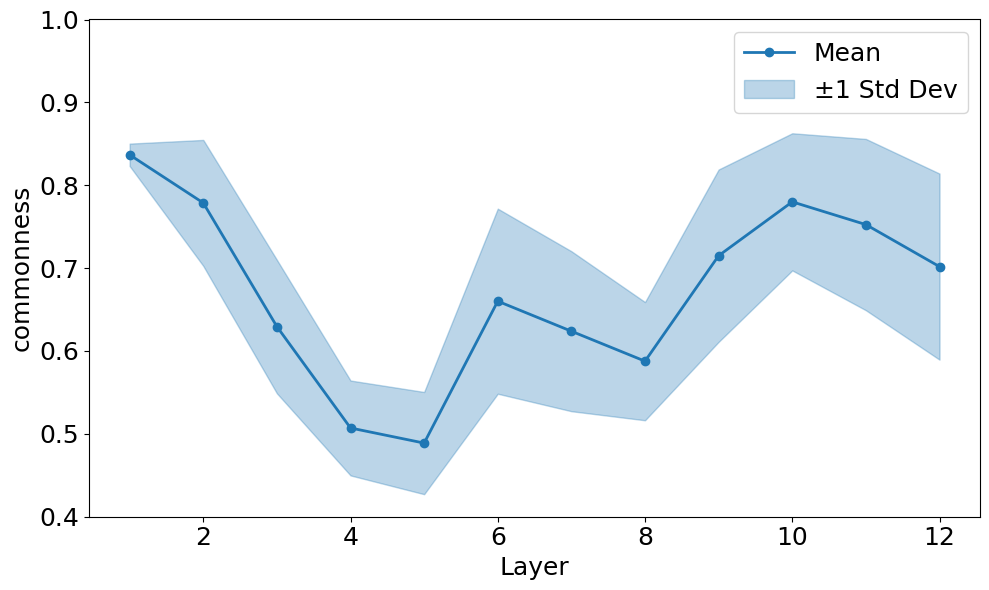

In [9]:
# Plot mean of head-wise stability (per layer) with std dev as shaded error band
layer_means = []
layer_stds = []
for layer in ticklabel_layers:
    layer_df = df_intra_layer_sim[df_intra_layer_sim['layer'] == layer]
    mean_cos_sim = layer_df['cos_sim'].mean()
    std_cos_sim = layer_df['cos_sim'].std()
    layer_means.append(mean_cos_sim)
    layer_stds.append(std_cos_sim)

plt.figure(figsize=(10, 6))

# Plot mean with shaded error band (±1 std dev)
plt.plot(ticklabel_layers, layer_means, marker='o', label='Mean', color='tab:blue', linewidth=2)
plt.fill_between(ticklabel_layers, 
                 np.array(layer_means) - np.array(layer_stds), 
                 np.array(layer_means) + np.array(layer_stds), 
                 alpha=0.3, color='tab:blue', label='±1 Std Dev')

plt.ylim(0.4, 1)
plt.xlabel('Layer', fontsize=18)
plt.ylabel('commonness', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
#plt.title('Layer-wise commonness with Standard Deviation')
plt.tight_layout()
plt.show()


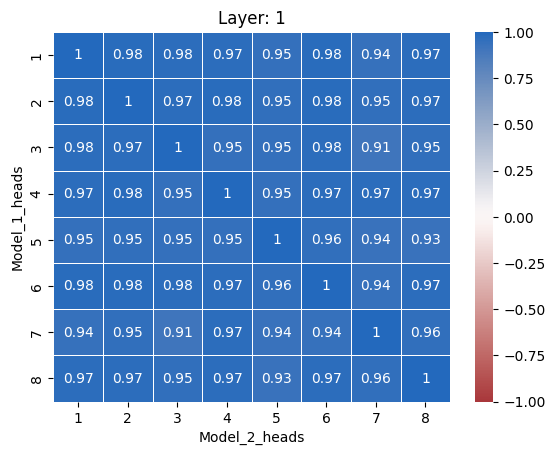

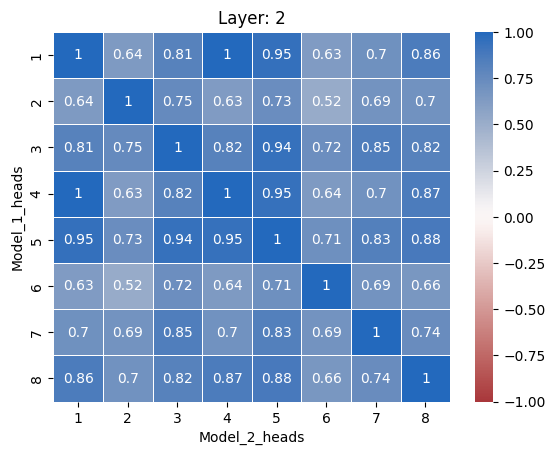

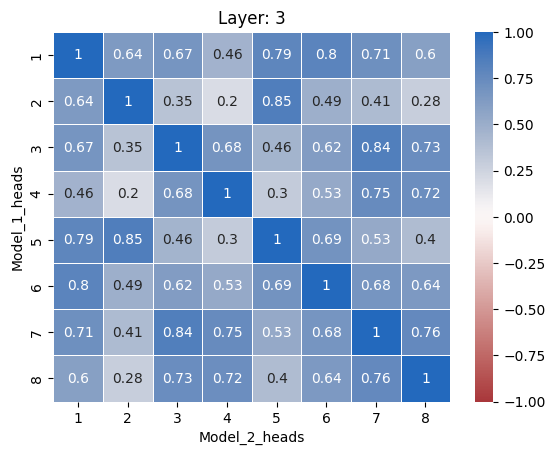

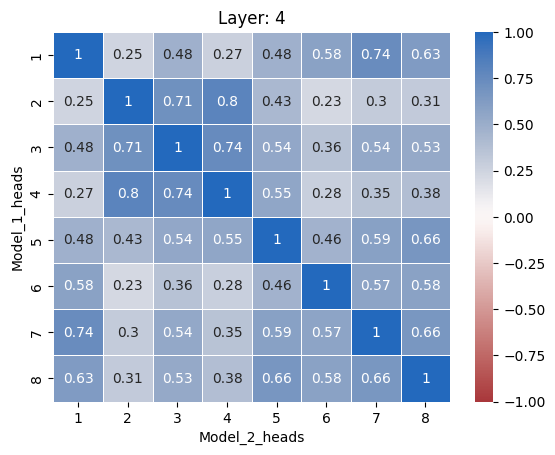

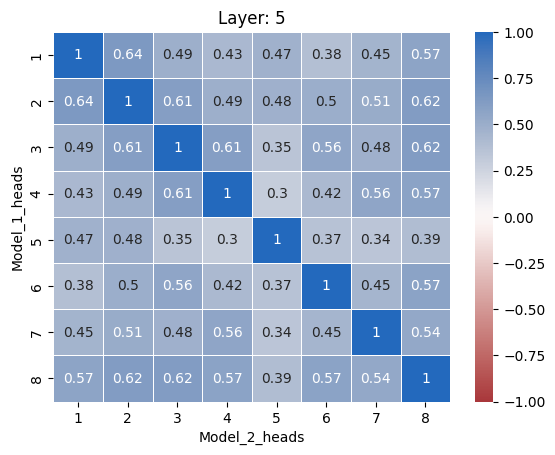

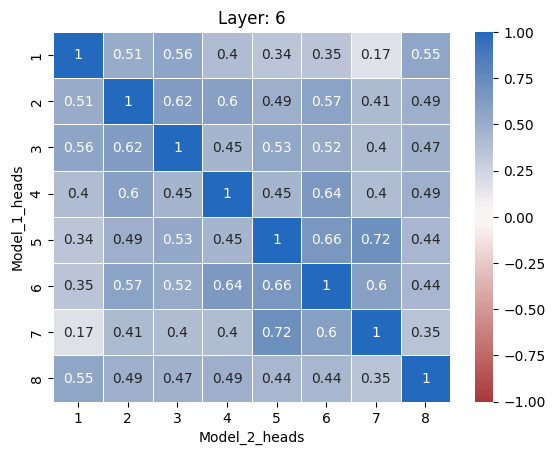

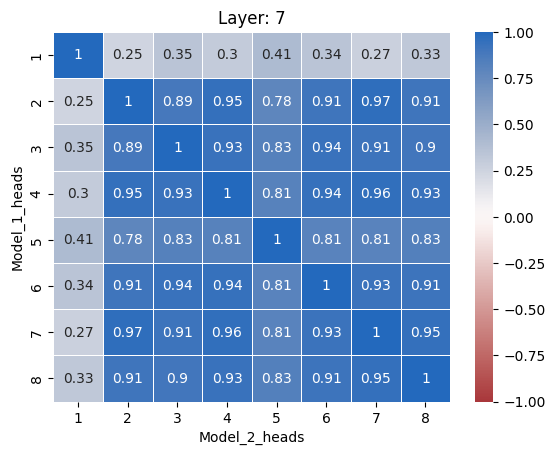

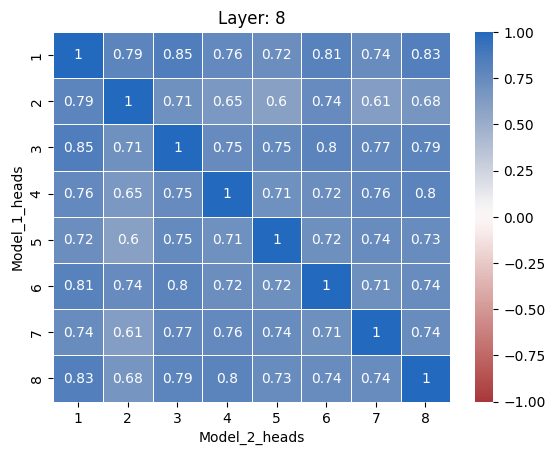

In [14]:
# Plot heatmaps for each layer
for layer_i in range(NUM_LAYERS):
    
    csh = prompts_cs_matrix[layer_i,:,:,:]
    csh = torch.mean(csh, -1)  
     
    ax = sns.heatmap(csh, vmin=-1, vmax=1,linewidth=0.5, cmap='vlag_r', xticklabels=ticklabel_heads, yticklabels=ticklabel_heads, annot=True)
    ax.set(xlabel='Model_2_heads', ylabel='Model_1_heads')
    ax.set_title(f"Layer: {layer_i+1}")

    plt.show()